# Fitting the score
In this notebook, we try a different approach aimed at directly fitting the score.

### Initial dataset
We first prepare an initial dataset for model training in the deployed application.  We start from the labeled headlines collected in notebooks 1 and 2, and proceed to clean and score them.

The training dataset is a dataframe of `sequence` (`str`), `embedding` (`np.array`), `relevant` (`0` or `1`), `score` (`float`), `user_feedback` (`bool`).

In [ ]:
import pandas as pd

df = pd.read_csv("data/labeled_headlines.csv")
df = df[df.relevant != -1]
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(inplace=True)
df.drop(columns=["title", "description", "timestamp", "index"], inplace=True)

df

We add the embeddings

In [ ]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("ProsusAI/finbert")
df["embedding"] = embedder.encode(df.concat.to_list(), show_progress_bar=True).tolist()

and we score the relevant headlines (`jittery` is set to 0 if the classifier is below 0.5, is set to 1 if above 0.8)

In [ ]:
from transformers import pipeline
import torch

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else ("mps" if torch.mps.is_available() else "cpu")
)

print("Device:", device)

classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=device,
    dtype=torch.float16,
)

candidate_labels = ["jittery", "non-jittery"]

In [ ]:
from tqdm import tqdm

tqdm.pandas()


def scorer(row):
    if row["relevant"] != 1:
        return None

    result = classifier(row["concat"], candidate_labels=candidate_labels)
    return dict(zip(result["labels"], result["scores"]))["jittery"]


df["jitter"] = df.progress_apply(scorer, axis=1)

In [ ]:
df = df.reindex(columns=["concat", "embedding", "relevant", "jitter"])

The training dataset is saved as csv file.

In [ ]:
df.to_csv("score_training.csv", index=False)

To use the dataset, load the csv file and evaluate the `embedding` column to convert it from string to list.

In [1]:
import pandas as pd
import numpy as np
import ast

df = pd.read_csv("score_training.csv")
df["embedding"] = df.embedding.apply(ast.literal_eval)

df

,concat,embedding,relevant,jitter
0,Are These the Bones of the Fourth Musketeer? T...,"[0.09192849695682526, 0.2081747204065323, 0.06...",0,NaN
1,Trump Is in China as Iran War Continues With N...,"[-0.24815446138381958, -0.020585568621754646, ...",1,0.894881
2,A Tech Tycoon’s Prosecution Raises Fears of Au...,"[-0.12966248393058777, -0.032048966735601425, ...",1,0.978208
3,"Catherine, Princess of Wales, to Make First Of...","[-0.3431681990623474, 0.28847524523735046, 0.3...",0,NaN
4,Why A.I. is the Hidden Minefield of Trump’s Ch...,"[-0.11767198890447617, 0.24949780106544495, -0...",1,0.920932
...,...,...,...,...
2475,Kane Parsons: From YouTube Sensation to A24’s ...,"[0.3171890079975128, 0.48437705636024475, 0.34...",0,NaN
2476,Jimmy Kimmel Finds Glee in President Trump’s A...,"[-0.17431640625, 0.09732984751462936, 0.259438...",0,NaN
2477,"Book Review: ‘Found Sound,’ by Meg Wolitzer an...","[0.15988008677959442, 0.3671722412109375, -0.0...",0,NaN
2478,She Said Yes. Then a Crowd at Madison Square G...,"[0.07557632774114609, 0.11724021285772324, 0.3...",0,NaN


### Fitting relevance
We first fit relevance.  We need to balance the classes.

In [ ]:
from sklearn.utils import resample

relevant_class = df[df.relevant == 1]
irrelevant_class = df[df.relevant == 0]

relevant_downsampled = resample(
    relevant_class, replace=False, n_samples=len(irrelevant_class), random_state=42
)

df_balanced = (
    pd.concat([relevant_class, irrelevant_class])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

Then create a train-test split.

In [3]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    df_balanced.embedding, df_balanced.relevant, shuffle=True, random_state=42
)

X_train = np.stack(X_train.values)
X_test = np.stack(X_test.values)
y_train = y_train.values
y_test = y_test.values

And explore dense neural networks.

In [ ]:
import os

os.environ["KERAS_BACKEND"] = "torch"

import keras

keras.utils.set_random_seed(42)

nn = keras.Sequential(
    layers=[
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
    ]
)

nn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

We do k-fold validation.

In [32]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

histories = []

for train_idx, val_idx in kf.split(X_train):
    X_tt, X_val = X_train[train_idx], X_train[val_idx]
    y_tt, y_val = y_train[train_idx], y_train[val_idx]

    scores = {}

    history = nn.fit(
        X_tt,
        y_tt,
        batch_size=128,
        epochs=30,
        validation_data=(X_val, y_val),
        verbose=0,
    )

    histories.append(history.history)

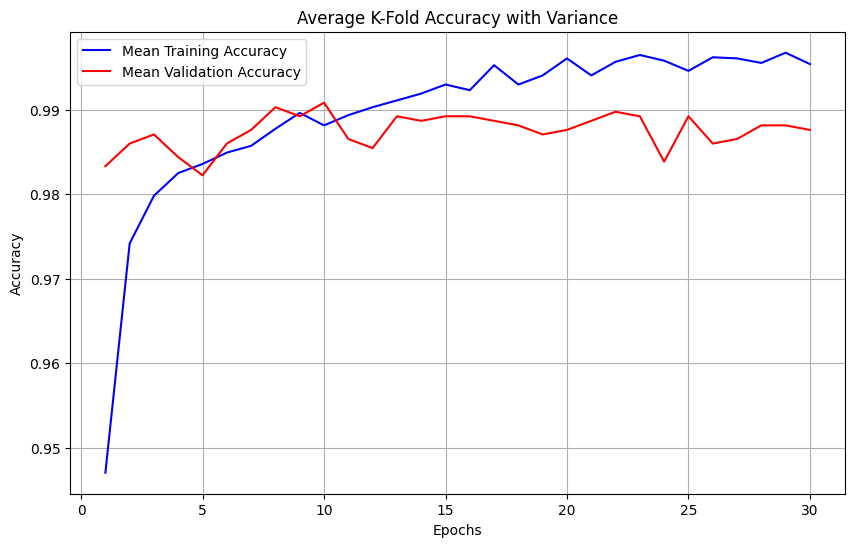

In [ ]:
import matplotlib.pyplot as plt

# Convert history list to a 2D numpy array (shape: folds, epochs)
train_acc_all = np.array([hist["accuracy"] for hist in histories])
val_acc_all = np.array([hist["val_accuracy"] for hist in histories])

# Calculate mean and standard deviation across folds
mean_train_acc = np.mean(train_acc_all, axis=0)
std_train_acc = np.std(train_acc_all, axis=0)
mean_val_acc = np.mean(val_acc_all, axis=0)
std_val_acc = np.std(val_acc_all, axis=0)

epochs = range(1, len(mean_train_acc) + 1)

plt.figure(figsize=(10, 6))

# Plot mean lines
plt.plot(epochs, mean_train_acc, "b-", label="Mean Training Accuracy")
plt.plot(epochs, mean_val_acc, "r-", label="Mean Validation Accuracy")

# # Fill standard deviation area to show variance
# plt.fill_between(epochs, mean_train_acc - std_train_acc, mean_train_acc + std_train_acc, color='blue', alpha=0.15)
# plt.fill_between(epochs, mean_val_acc - std_val_acc, mean_val_acc + std_val_acc, color='red', alpha=0.15)

plt.title("Average K-Fold Accuracy with Variance")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

It seems that this architecture performs well around the 10 epochs.  Hence, we retrain on the full `X_train, y_train` for 10 epochs and test on the testing set `X_test, y_test`.

In [ ]:
nn.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=10,
    verbose=0,
)

results = nn.evaluate(X_test, y_test, return_dict=True)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9597 - loss: 0.3213


In [37]:
results

{'accuracy': 0.9596773982048035, 'loss': 0.3213270902633667}

This is very good. However, it does not beat a simple logistic regression model.

In [39]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score

logit = LogisticRegressionCV(cv=5)

logit.fit(X_train, y_train)

accuracy_score(y_test, logit.predict(X_test))

/Users/ralbesia/Projects/jitter/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/ralbesia/Projects/jitter/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


0.9612903225806452

We stick to the logistic regression model.

### Fitting scores
Now we look at scores. First, we discard all non-relevant headlines.

In [41]:
df_rel = df[df.relevant == 1]

Then create a train-test split.

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    df_rel.embedding, df_rel.jitter, shuffle=True, random_state=42
)

X_train = np.stack(X_train.values)
X_test = np.stack(X_test.values)
y_train = y_train.values[:, np.newaxis]
y_test = y_test.values[:, np.newaxis]

And explore dense neural networks.

In [134]:
nn = keras.Sequential(
    layers=[
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(1, activation="sigmoid"),
    ]
)

nn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["mae"])

We do k-fold validation.

In [135]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

histories = []

for train_idx, val_idx in kf.split(X_train):
    X_tt, X_val = X_train[train_idx], X_train[val_idx]
    y_tt, y_val = y_train[train_idx], y_train[val_idx]

    scores = {}

    history = nn.fit(
        X_tt,
        y_tt,
        batch_size=128,
        epochs=100,
        validation_data=(X_val, y_val),
    )

    histories.append(history.history)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6614 - mae: 0.2149 - val_loss: 0.6122 - val_mae: 0.1673
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6238 - mae: 0.1783 - val_loss: 0.5987 - val_mae: 0.1495
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6179 - mae: 0.1753 - val_loss: 0.5993 - val_mae: 0.1542
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6133 - mae: 0.1712 - val_loss: 0.5911 - val_mae: 0.1449
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6065 - mae: 0.1640 - val_loss: 0.5869 - val_mae: 0.1412
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6024 - mae: 0.1606 - val_loss: 0.5834 - val_mae: 0.1369
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5998 - mae: 0.1572 - val_loss: 0.5817 - val_mae: 0.1351
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5958 - mae: 0.1555 - val_loss: 0.5788 - val_mae: 0.1319
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5930 - mae: 0.1490 - 

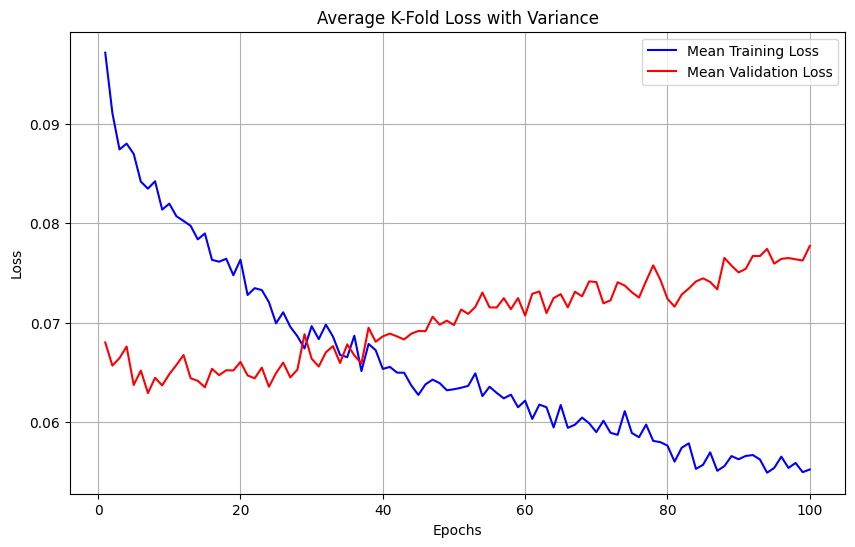

In [136]:
import matplotlib.pyplot as plt

# Convert history list to a 2D numpy array (shape: folds, epochs)
train_loss_all = np.array([hist["mae"] for hist in histories])
val_loss_all = np.array([hist["val_mae"] for hist in histories])

# Calculate mean and standard deviation across folds
mean_train_loss = np.mean(train_loss_all, axis=0)
std_train_loss = np.std(train_loss_all, axis=0)
mean_val_loss = np.mean(val_loss_all, axis=0)
std_val_loss = np.std(val_loss_all, axis=0)

epochs = range(1, len(mean_train_loss) + 1)

plt.figure(figsize=(10, 6))

# Plot mean lines
plt.plot(epochs, mean_train_loss, "b-", label="Mean Training Loss")
plt.plot(epochs, mean_val_loss, "r-", label="Mean Validation Loss")

# # Fill standard deviation area to show variance
# plt.fill_between(epochs, mean_train_loss - std_train_loss, mean_train_loss + std_train_loss, color='blue', alpha=0.15)
# plt.fill_between(epochs, mean_val_loss - std_val_loss, mean_val_loss + std_val_loss, color='red', alpha=0.15)

plt.title("Average K-Fold Loss with Variance")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

The best validation loss seems to be around 7 epochs. Hence, we retrain on the full `X_train, y_train` for 7 epochs and test on the testing set `X_test, y_test`.

In [137]:
nn.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=7,
    verbose=0,
)

results = nn.evaluate(X_test, y_test, return_dict=True)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5710 - mae: 0.1341


In [138]:
results

{'loss': 0.5709571838378906, 'mae': 0.13411679863929749}

Given that the targets are in $[0,1]$, this is not really a very good fit.  However, remember that the `jitter` score is a fairly arbitrary score itself, that only approximately reflects the ambiguous notion of "jitter".  If we use the model as an approximate way to quantify our vague notion of jitter, then it is not that worse than the arbitrary zero-shot quantifier (but much more efficient).  We will use this model.